In [2]:
# ============================================================
# CARGA Y COMBINACIÓN DE DATOS — HOJAS 5A y 5B
# Se leen ambas hojas del documento de Google Sheets y se
# concatenan en un único DataFrame para tratarlos como
# un solo conjunto de datos.
# ============================================================

from google.colab import auth
import gspread
from google.auth import default
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Autenticación en Google
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Apertura del documento de Google Sheets
file_id = '11vJXajjCLX1-LJeQ3FXsCo_yr-zZv49mnHq-6MDlhqw'
sh = gc.open_by_key(file_id)

# ---- Lectura de la hoja 5A ----
datos_5A = sh.worksheet('5A').get('A1:E23')
df_5A = pd.DataFrame(datos_5A[1:], columns=datos_5A[0])

# ---- Lectura de la hoja 5B ----
datos_5B = sh.worksheet('5B').get('A1:E25')
df_5B = pd.DataFrame(datos_5B[1:], columns=datos_5B[0])

# ---- Combinación de ambos grupos en un solo DataFrame ----
# ignore_index=True renumera los índices desde 0 de forma continua
df = pd.concat([df_5A, df_5B], ignore_index=True)

# Verificación del resultado
print(f"Alumnos en 5A  : {len(df_5A)}")
print(f"Alumnos en 5B  : {len(df_5B)}")
print(f"Total combinado: {len(df)}")
print()
print(df.head())

Alumnos en 5A  : 22
Alumnos en 5B  : 24
Total combinado: 46

  No.  Matrícula           Nombre del Estudiante Altura (cm) Peso (KG)
0   1  243112024         ARTEAGA CASTILLO ISRAEL         189       104
1   2  243110670     AVILA ENCISO GUILLERMO JOSE         176        90
2   3  243111514         AVILA JUAREZ JOSE ANGEL         182       110
3   4  243110528           AVILA VAZQUEZ ARMANDO         172        87
4   5  243111280  CERON TRUJILLO XAVIER APOLINAR         170        63


In [3]:
# ============================================================
# CÁLCULO DEL COEFICIENTE DE CORRELACIÓN (r)
# Se aplica la fórmula de Pearson sobre el conjunto combinado.
#
# Variables:
#   x = Altura (cm) → variable independiente
#   y = Peso (KG)   → variable dependiente
# ============================================================

# Extracción y conversión numérica de las columnas del DataFrame combinado
x = pd.to_numeric(df['Altura (cm)'], errors='coerce')
y = pd.to_numeric(df['Peso (KG)'],   errors='coerce')

# Sumas necesarias para la fórmula de Pearson
n      = len(x)
sum_x  = x.sum()
sum_y  = y.sum()
sum_xy = (x * y).sum()
sum_x2 = (x ** 2).sum()
sum_y2 = (y ** 2).sum()

# Coeficiente de correlación de Pearson
r = (n * sum_xy - sum_x * sum_y) / \
    np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))

print(f"n total (ambos grupos) = {n}")
print(f"Coeficiente de correlación r = {r:.4f}")

n total (ambos grupos) = 46
Coeficiente de correlación r = 0.6936


In [4]:
# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS DEL CONJUNTO COMBINADO
# ============================================================

media_x = x.mean()
media_y = y.mean()
std_x   = x.std()
std_y   = y.std()

print(f"Media X (Altura): {media_x:.4f} cm")
print(f"Media Y (Peso):   {media_y:.4f} kg")
print(f"Desv. Est. X:     {std_x:.4f}")
print(f"Desv. Est. Y:     {std_y:.4f}")

Media X (Altura): 169.8696 cm
Media Y (Peso):   69.1739 kg
Desv. Est. X:     8.4317
Desv. Est. Y:     16.1868


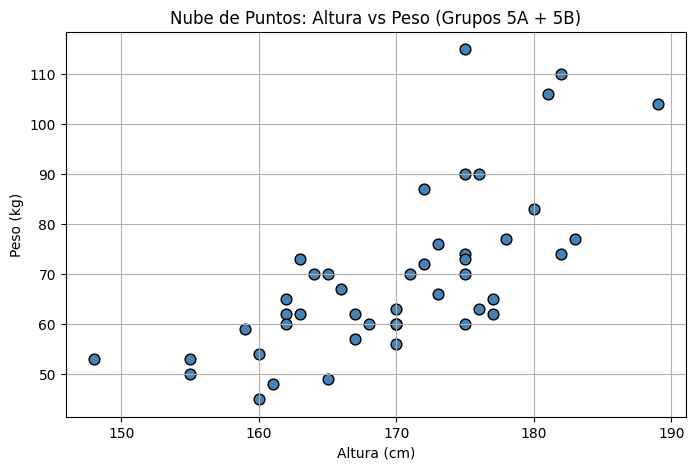

In [5]:
# ============================================================
# GRÁFICA 1: NUBE DE PUNTOS — CONJUNTO COMBINADO
# Todos los alumnos de 5A y 5B aparecen como un único
# conjunto de datos.
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(x, y, color='steelblue', edgecolors='black', s=60)

plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Nube de Puntos: Altura vs Peso (Grupos 5A + 5B)')
plt.grid(True)
plt.show()

In [6]:
# ============================================================
# CÁLCULO DE LOS COEFICIENTES DE LA RECTA DE REGRESIÓN
# ============================================================

# Pendiente de la recta
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

# Intercepto con el eje Y
b = (sum_y - m * sum_x) / n

print(f"Pendiente  m = {m:.4f}")
print(f"Intercepto b = {b:.4f}")
print(f"Ecuación:  y = {m:.4f}x + ({b:.4f})")

Pendiente  m = 1.3316
Intercepto b = -157.0226
Ecuación:  y = 1.3316x + (-157.0226)


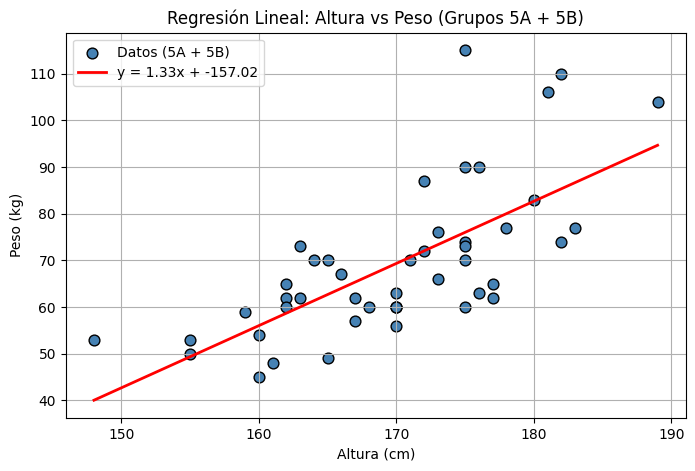

In [7]:
# ============================================================
# GRÁFICA 2: NUBE DE PUNTOS + RECTA DE REGRESIÓN
# ============================================================

x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

plt.figure(figsize=(8, 5))

plt.scatter(x, y, color='steelblue', edgecolors='black', s=60, label='Datos (5A + 5B)')
plt.plot(x_linea, y_linea, color='red', linewidth=2,
         label=f'y = {m:.2f}x + {b:.2f}')

plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Regresión Lineal: Altura vs Peso (Grupos 5A + 5B)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# ============================================================
# PREDICCIÓN
# ============================================================

altura_pred = 175
peso_pred   = m * altura_pred + b

print(f"Para una altura de {altura_pred} cm:")
print(f"Peso estimado = {peso_pred:.2f} kg")

Para una altura de 175 cm:
Peso estimado = 76.01 kg


Pendiente  m = 1.3316
Intercepto b = -157.0226
Ecuación:  y = 1.3316x + (-157.0226)
Coef. correlación r = 0.6936
Error estándar Se = 11.7917 kg


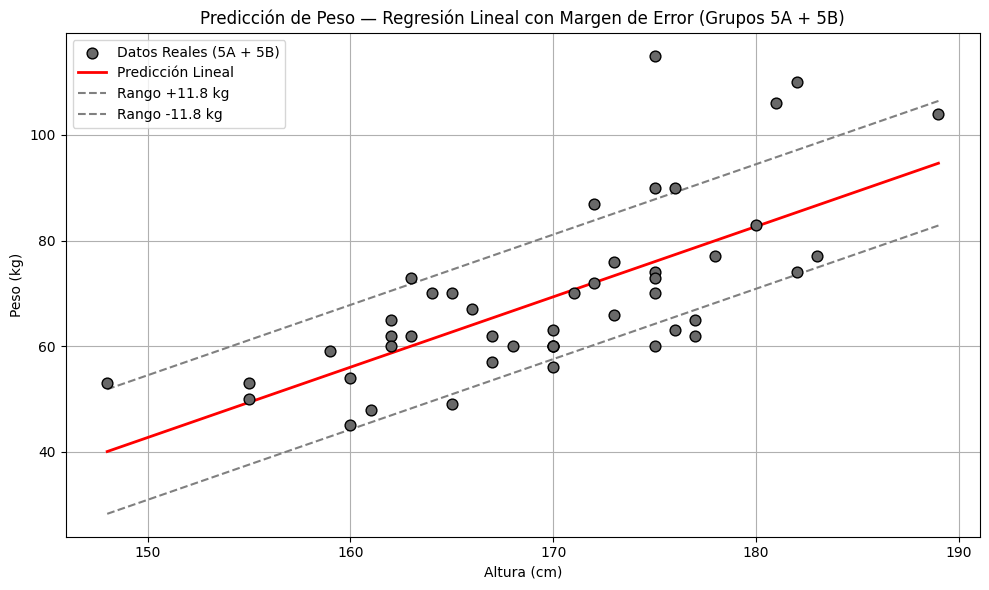

In [9]:
# ============================================================
# GRÁFICA 3: REGRESIÓN LINEAL CON MÁRGENES DE ERROR (±Se)
# ============================================================

from scipy import stats

# Recalculamos m y b (para que la celda sea autónoma)
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
b = (sum_y - m * sum_x) / n

# Error estándar de estimación
y_pred = m * x + b
Se = np.sqrt(((y - y_pred)**2).sum() / (n - 2))

print(f"Pendiente  m = {m:.4f}")
print(f"Intercepto b = {b:.4f}")
print(f"Ecuación:  y = {m:.4f}x + ({b:.4f})")
print(f"Coef. correlación r = {r:.4f}")
print(f"Error estándar Se = {Se:.4f} kg")

x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='dimgray', edgecolors='black', s=60,
            label='Datos Reales (5A + 5B)', zorder=5)
plt.plot(x_linea, y_linea,
         color='red', linewidth=2, linestyle='-',
         label='Predicción Lineal')
plt.plot(x_linea, y_linea + Se,
         color='gray', linewidth=1.5, linestyle='--',
         label=f'Rango +{Se:.1f} kg')
plt.plot(x_linea, y_linea - Se,
         color='gray', linewidth=1.5, linestyle='--',
         label=f'Rango -{Se:.1f} kg')

plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Predicción de Peso — Regresión Lineal con Margen de Error (Grupos 5A + 5B)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()